In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.covariance import MinCovDet
import scipy.stats as stats

In [3]:
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


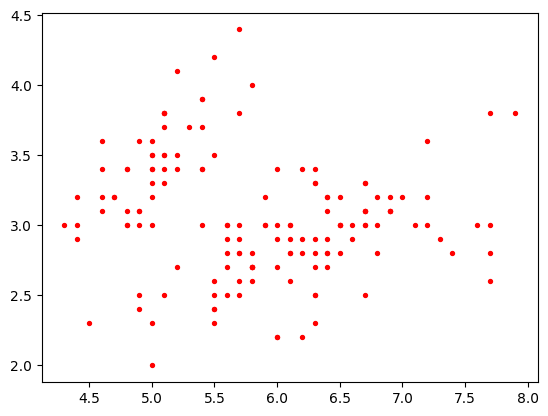

In [8]:
plt.scatter(iris['sepal_length'], iris['sepal_width'], color='red', s=8)

(-5.187395654818074, 8.945881868971734)

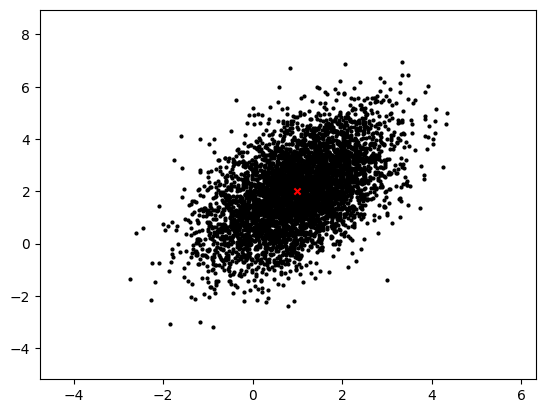

In [ ]:
mu = [1,2]
sigma = [[1,0.7],[0.7,2]]
x = np.random.multivariate_normal(mu, sigma, size=5000)
plt.scatter(x[:,0], x[:,1], s=4, color='black')
plt.scatter(mu[0], mu[1], marker='x', color='red', s=20)
plt.xlim([x[:,0].min()-2, x[:,0].max()+2])
plt.ylim([x[:,1].min()-2, x[:,1].max()+2])

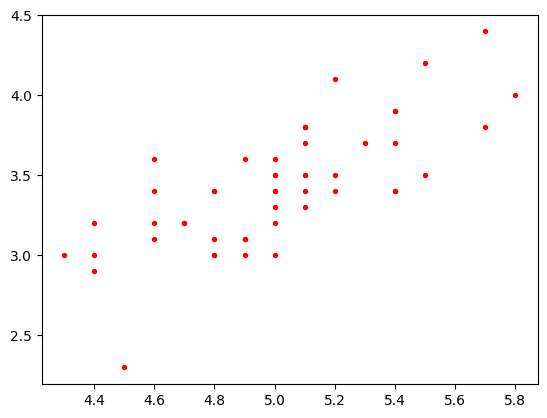

In [ ]:

setosa = iris[iris['species']=='setosa']
plt.scatter(setosa['sepal_length'], setosa['sepal_width'], color='red', s=8)

In [27]:
y = setosa[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
model = MinCovDet(random_state = 42).fit(y)
setosa['D2'] = model.mahalanobis(y)

# assuming eliptical nature: D**2 follows a chi2 with ddof 4
# cutoff value for outliers:

alpha = 0.01 
n =  4
cutoff = stats.chi2.ppf(1-alpha, n)
cutoff

C:\Users\109149\AppData\Local\Temp\ipykernel_2652\3582063408.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  setosa['D2'] = model.mahalanobis(y)


np.float64(13.276704135987622)

In [35]:
mu_model = model.location_

In [43]:
outliers = setosa[setosa['D2']>=cutoff]

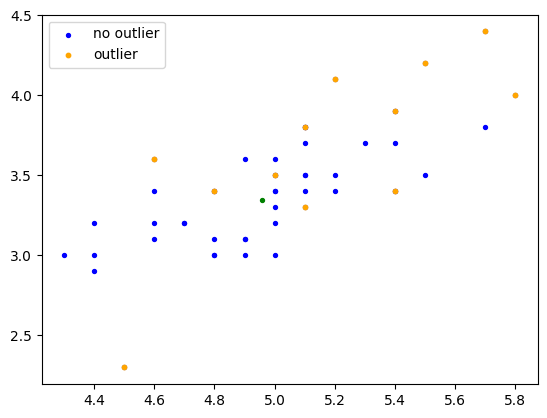

In [44]:
plt.scatter(setosa['sepal_length'], setosa['sepal_width'], color='blue', s=8, label='no outlier')
plt.scatter(outliers['sepal_length'], outliers['sepal_width'], color='orange', s=10, label='outlier')
plt.scatter(mu_model[0], mu_model[1], color='green', s=8)
plt.legend()